# **FICO® Xpress MoselPy - Chapter F: Air Transport**

***air_transport.ipynb*** - Air transport and logistics problems from the Xpress Applications Book - flight connections, crew assignment, landing scheduling, hub network design, and tour planning, solved with MoselPy.

&copy; Copyright 2026 Fair Isaac Corporation. The use of this example is subject to [legal and license requirements](https://github.com/fico-xpress/xpress-community#legal-and-license-requirements).

In [ ]:
# Install the necessary packages
%pip install -q moselpy mosellibs xpresslibs matplotlib pandas

Run the cell below to import the necessary libraries and set `MODELS` and `DATA`, the path variables pointing to the Mosel model files and data files used in this notebook.

In [ ]:
import moselpy as mp
from moselpy import ExecStatus
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

MODELS = "models/air_transport"
DATA   = "data/air_transport"

print(f"MoselPy {mp.version}  |  Mosel {mp.mosel_version}  |  Xpress {mp.xpress_version}")
mp.config.set_default_stream(mp.StreamType.OUTPUT, "null:")

MoselPy 6.12.0  |  Mosel 6012000  |  Xpress 10000000


## Air transport and logistics

This notebook covers five LP and MIP examples from Chapter F of the Xpress Applications Book, solved via [MoselPy](https://pypi.org/project/moselpy/). Examples range from flight connection planning and crew assignment to landing scheduling, hub-and-spoke network design, and tour planning via subtour elimination.

> **Mosel source files:** [`models/air_transport/`](models/air_transport/) &nbsp;|&nbsp; **Data files:** [`data/air_transport/`](data/air_transport/)

> **Requirements:** `pip install moselpy mosellibs xpresslibs` - `mosellibs` provides the Mosel runtime and `xpresslibs` the Xpress solver libraries. No local Xpress installation is needed to run these notebooks, as long as the packages with libraries have been installed.

> A local FICO&reg; Xpress installation is recommended if you want access to the full set of examples, user guides and documentation, solver libraries, and Xpress Workbench. Obtain one via the [FICO&reg; Xpress community license](https://www.fico.com/en/fico-xpress-community-license) page. If a local installation is present, set `XPRESSDIR` before starting Jupyter to use it instead of the `mosellibs` and `xpresslibs` packages.

> **MoselPy documentation:** [MoselPy User Guide and Reference Manual](https://www.fico.com/fico-xpress-optimization/docs/latest/mosel/MoselPy/dhtml)

> **Mosel examples on the web:** [examples.xpress.fico.com](https://examples.xpress.fico.com/example.pl?id=mosel_app_6)

### MoselPy features demonstrated in this chapter

- **Single execution command** (`mp.execute_model()`): run F-1 in a single call, inspect the binary connection matrix.
- **Compile-load-run sequence with dynamic sets**: F-2 uses a computed `ARCS` range whose size depends on the data; the adapted model preprocesses crew compatibility before finalizing the set.
- **Sequential multi-objective MIP**: F-2 demonstrates two consecutive `maximize()` calls within a single model run, with intermediate results captured between objectives.
- **`model.find_identifier()`**: retrieve the `sol_land` array after solving F-3 directly from the model object, as an alternative to the `initializations to OUTFILE` dict.
- **Model introspection**: `model.name`, `model.version`, `model.user_comment`, and `model.size` are demonstrated on F-4.
- **Context manager** (`with mp.load_model(...) as model:`): F-5 uses the context manager form to ensure model resources are released automatically after the tour planning run.
- **`setcallback(XPRS_CB_PREINTSOL, ...)`**: F-5 (variant) registers a pre-integer-solution callback in Mosel that adds lazy subtour-elimination cuts during B&B, so Python calls `execute_model` once and the solver handles all constraint generation internally.

## F-1 Flight connection planning (MIP)

*Applications Book Chapter F, Example 1*

> **Mosel model:** [`f1connect_p.mos`](models/air_transport/f1connect_p.mos)

An airline has 6 planes landing at a hub within 90 minutes. During the following hour, these planes must travel to 6 new destinations. For each incoming/outgoing pair, the matrix `PASS[i,j]` gives the number of passengers who can stay on board if plane $i$ continues to destination $j$. Infeasible connections are represented by a large negative value $(-1000)$. The model assigns each incoming plane to one outgoing flight to maximize the total number of passengers who remain on their plane.

This is an assignment problem: each incoming flight is matched exactly once to an outgoing flight and vice versa.

**Sets:** $\text{PLANES} = \{1, \ldots, 6\}$

**Parameters:** $\text{PASS}_{i,j}$ - passengers staying on board if plane $i$ continues to $j$ ($-1000$ for infeasible connections)

**Decision variables:** $\mathit{cont}_{i,j} \in \{0,1\}$ - 1 if incoming flight $i$ continues to destination $j$

$$
\begin{align*}
\text{maximize}   \quad & \sum_{i,j \in \text{PLANES}} \text{PASS}_{i,j} \cdot \mathit{cont}_{i,j} \\
\text{subject to} \quad & \sum_{j} \mathit{cont}_{i,j} = 1 \quad \forall\, i \in \text{PLANES} \\
                          & \sum_{i} \mathit{cont}_{i,j} = 1 \quad \forall\, j \in \text{PLANES}
\end{align*}
$$

Define the 6x6 passenger connection matrix `PASS` as a Python dict with 1-indexed `(i,j)` tuple keys. Entries of $-1000$ represent infeasible connections (e.g. a narrow-body plane cannot continue on a wide-body route). Passing the matrix as a flat dict is the standard pattern for 2D integer arrays.

In [ ]:
# Passenger matrix: PASS[i,j] = passengers staying on board if plane i continues to j
# -1000 encodes an infeasible connection (too few seats)
pass_raw = [
    [  35,  12,  16,  38,   5,   2],
    [  25,   8,   9,  24,   6,   8],
    [  12,   8,  11,  27,   3,   2],
    [  38,  15,  14,  30,   2,   9],
    [-1000,  9,   8,  25,  10,   5],
    [-1000,-1000,-1000,14,  6,   7],
]
PASS = {(i+1, j+1): v for i, row in enumerate(pass_raw) for j, v in enumerate(row)}

import pandas as pd
pass_df = pd.DataFrame(pass_raw, index=range(1,7), columns=range(1,7))
pass_df.index.name   = "Incoming"
pass_df.columns.name = "Outgoing"
print("Passenger connection matrix (PASS):")
print(pass_df.to_string())

Passenger connection matrix (PASS):
Outgoing     1     2     3   4   5  6
Incoming                             
1           35    12    16  38   5  2
2           25     8     9  24   6  8
3           12     8    11  27   3  2
4           38    15    14  30   2  9
5        -1000     9     8  25  10  5
6        -1000 -1000 -1000  14   6  7


Use the single execution command. `PASS` is passed via `input_data` as a dict with `(i,j)` tuple keys, matching the Mosel 2D array declaration `cont: array(PLANES,PLANES) of mpvar`. After solving, `sol_cont` gives the binary assignment matrix.

In [ ]:
model, output = mp.execute_model(
    f"{MODELS}/f1connect_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"PASS": PASS},
)

if model.prob_status.is_solution_available:
    obj_val_f1 = output["obj_val"]
    sol_cont   = output["sol_cont"]

    # Reconstruct assignment: for each incoming plane i, find which outgoing j it connects to
    assignment = {i: next(j for j in range(1,7) if sol_cont.get((i,j), 0) > 0.5)
                  for i in range(1,7)}
    passengers = {i: pass_raw[i-1][assignment[i]-1] for i in range(1,7)}

    print(f"Total passengers staying on board: {obj_val_f1:.0f}")
    print()
    print(f"{'Incoming':>9}  {'-> Outgoing':>12}  {'Passengers':>12}")
    for i in range(1, 7):
        j = assignment[i]
        pax = passengers[i]
        feasible = "" if pax >= 0 else "  (infeasible - would have been 0)"
        print(f"  Plane {i:>2}  ->   Plane {j:>2}      {pax:>8}{feasible}")
else:
    print(f"No solution found ({model.prob_status})")

Total passengers staying on board: 112

 Incoming   -> Outgoing    Passengers
  Plane  1  ->   Plane  4            38
  Plane  2  ->   Plane  2             8
  Plane  3  ->   Plane  3            11
  Plane  4  ->   Plane  1            38
  Plane  5  ->   Plane  5            10
  Plane  6  ->   Plane  6             7


Heatmap of the connection matrix `PASS`. The optimal assignment is marked with circles; infeasible connections are shown in red.

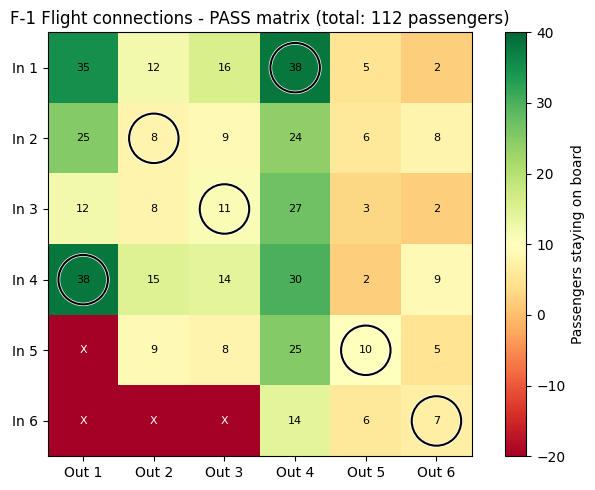

In [ ]:
if "assignment" in locals() and "sol_cont" in locals():
    fig, ax = plt.subplots(figsize=(7, 5))

    # Build display matrix: clip infeasible to -20 for color contrast
    disp = np.array([[max(pass_raw[i][j], -20) for j in range(6)] for i in range(6)], dtype=float)

    im = ax.imshow(disp, cmap="RdYlGn", aspect="equal", vmin=-20, vmax=40)
    plt.colorbar(im, ax=ax, label="Passengers staying on board")

    ax.set_xticks(range(6)); ax.set_xticklabels([f"Out {j}" for j in range(1,7)])
    ax.set_yticks(range(6)); ax.set_yticklabels([f"In {i}"  for i in range(1,7)])
    ax.set_title(f"F-1 Flight connections - PASS matrix (total: {obj_val_f1:.0f} passengers)")

    # Mark optimal assignment with circles
    for i in range(1, 7):
        j = assignment[i]
        ax.add_patch(plt.Circle((j-1, i-1), 0.35, color="white", fill=False, lw=2.5))
        ax.add_patch(plt.Circle((j-1, i-1), 0.35, color="black", fill=False, lw=1.5))

    # Annotate all cells
    for i in range(6):
        for j in range(6):
            val = pass_raw[i][j]
            txt = str(val) if val > -100 else "X"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if val < -10 else "black")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping connection heatmap")

## F-2 Military crew composition (MIP)

*Applications Book Chapter F, Example 2*

> **Mosel model:** [`f2crew_p.mos`](models/air_transport/f2crew_p.mos)

The Royal Air Force (RAF) has 8 pilots who speak different languages and are trained on different aircraft types. Two pilots can form a crew only if they share at least one language with a rating of 10 or more, and share at least one aircraft type with a rating of 10 or more.

The model is solved in two phases:

1. **Phase 1** - maximize the number of crews flying (i.e. find the maximum matching).
2. **Phase 2** - keeping the same crew count, maximize the total combined aircraft type rating (quality score).

The model preprocesses the data to build the set `ARCS` of all feasible pilot pairs, which is finalized dynamically before the decision variables are declared.

**Sets:** $\text{PILOTS} = \{1, \ldots, 8\}$, $\text{RL}$ (languages), $\text{RT}$ (aircraft types), $\text{ARCS}$ (feasible crew pairs, computed from data)

**Parameters:** $\text{LANG}_{l,p}$ - language rating of pilot $p$; $\text{PTYPE}_{t,p}$ - aircraft type rating; $\text{SCORE}_a$ - combined type score of crew pair $a$

**Decision variables:** $\mathit{fly}_a \in \{0,1\}$ - 1 if crew $a$ is assigned to a flight

$$
\begin{align*}
\text{maximize}   \quad & \sum_{a \in \text{ARCS}} \mathit{fly}_a \qquad \text{(Phase 1: max crews)} \\
\text{maximize}   \quad & \sum_{a \in \text{ARCS}} \text{SCORE}_a \cdot \mathit{fly}_a \qquad \text{(Phase 2: max score)} \\
\text{subject to} \quad & \sum_{a:\, p \in \text{CREW}(a)} \mathit{fly}_a \leq 1 \quad \forall\, p \in \text{PILOTS}
\end{align*}
$$

Define `LANG` and `PTYPE` as dicts with `(language/type, pilot_index)` tuple keys. When MoselPy reads these dicts, the string dimensions (`RL` and `RT` in the Mosel model) are auto-populated from the first elements of the tuple keys.

In [ ]:
# Language ratings: (language, pilot) -> rating (0 = not proficient)
LANG = {
    ("English", 1):20, ("English", 2):14, ("English", 3): 0, ("English", 4):13,
    ("English", 5): 0, ("English", 6): 0, ("English", 7): 8, ("English", 8): 8,
    ("French",  1):12, ("French",  2): 0, ("French",  3): 0, ("French",  4):10,
    ("French",  5):15, ("French",  6):20, ("French",  7): 8, ("French",  8): 9,
    ("Dutch",   1): 0, ("Dutch",   2):20, ("Dutch",   3):12, ("Dutch",   4): 0,
    ("Dutch",   5): 8, ("Dutch",   6):11, ("Dutch",   7):14, ("Dutch",   8):12,
    ("Norwegian",1): 0,("Norwegian",2): 0,("Norwegian",3): 0,("Norwegian",4): 0,
    ("Norwegian",5):17,("Norwegian",6): 0,("Norwegian",7): 0,("Norwegian",8):16,
}
# Aircraft type ratings: (type, pilot) -> rating (0 = not qualified)
PTYPE = {
    ("reconnaissance", 1):18, ("reconnaissance", 2):12, ("reconnaissance", 3):15,
    ("reconnaissance", 4): 0, ("reconnaissance", 5): 0, ("reconnaissance", 6): 0,
    ("reconnaissance", 7): 8, ("reconnaissance", 8): 0,
    ("transport",  1):10, ("transport",  2): 0, ("transport",  3): 9, ("transport",  4):14,
    ("transport",  5):15, ("transport",  6): 8, ("transport",  7):12, ("transport",  8):13,
    ("bomber",     1): 0, ("bomber",     2):17, ("bomber",     3): 0, ("bomber",     4):11,
    ("bomber",     5):13, ("bomber",     6):10, ("bomber",     7): 0, ("bomber",     8): 0,
    ("fighter-bomber",1): 0, ("fighter-bomber",2): 0, ("fighter-bomber",3):14,
    ("fighter-bomber",4): 0, ("fighter-bomber",5): 0, ("fighter-bomber",6):12,
    ("fighter-bomber",7):16, ("fighter-bomber",8): 0,
    ("supply plane",1): 0, ("supply plane",2): 0, ("supply plane",3): 0,
    ("supply plane",4): 0, ("supply plane",5):12, ("supply plane",6):18,
    ("supply plane",7): 0, ("supply plane",8):18,
}

n_pilots    = max(p for (_, p) in LANG)
n_languages = len({l for (l, _) in LANG})
n_aircraft  = len({t for (t, _) in PTYPE})
print(f"Pilots: {n_pilots}  |  Languages: {n_languages}  |  Aircraft types: {n_aircraft}")

Pilots: 8  |  Languages: 4  |  Aircraft types: 5


Use the compile-load-run sequence. The model builds the feasible crew set `ARCS` internally during initialization, then solves two consecutive optimization problems. The output dict contains results from both phases: `obj_nflying` (Phase 1), `obj_score` (Phase 2), `sol_fly1`, `sol_fly2`, `CREW` (pilot pairs), and `SCORE` (quality scores).

The size of `ARCS` is determined at runtime from the data, making this model an example of dynamic set computation in Mosel.

In [ ]:
mp.compile_model(f"{MODELS}/f2crew_p.mos", f"{MODELS}/f2crew_p.bim")
model = mp.load_model(f"{MODELS}/f2crew_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"LANG": LANG, "PTYPE": PTYPE},
)

if model.prob_status.is_solution_available:
    obj_nflying = output["obj_nflying"]
    obj_score   = output["obj_score"]
    sol_fly1    = output["sol_fly1"]
    sol_fly2    = output["sol_fly2"]
    crew_raw    = output["CREW"]
    score_raw   = output["SCORE"]

    # Reconstruct pilot pairs: CREW[(a,1)] = pilot p, CREW[(a,2)] = pilot q
    num_arcs = max(a for (a, _) in crew_raw.keys())
    crews = [(int(crew_raw[(a,1)]), int(crew_raw[(a,2)])) for a in range(1, num_arcs+1)]
    scores = {a: int(score_raw[a]) for a in range(1, num_arcs+1)}

    flying1 = [a for a in range(1, num_arcs+1) if sol_fly1.get(a, 0) > 0.5]
    flying2 = [a for a in range(1, num_arcs+1) if sol_fly2.get(a, 0) > 0.5]

    print(f"Phase 1: maximum crews flying = {obj_nflying:.0f}")
    for a in flying1:
        p, q = crews[a-1]
        print(f"  Pilots {p} and {q}  (score: {scores[a]})")

    print()
    print(f"Phase 2: maximum total score = {obj_score:.0f}  (crews: {len(flying2)})")
    for a in flying2:
        p, q = crews[a-1]
        print(f"  Pilots {p} and {q}  (score: {scores[a]})")
else:
    print(f"No solution found ({model.prob_status})")

Mosel: W-226 at line 65 of `models/air_transport/f2crew_p.mos': Symbol `pmin' is never used.


Phase 1: maximum crews flying = 4
  Pilots 1 and 4  (score: 24)
  Pilots 2 and 3  (score: 27)
  Pilots 5 and 8  (score: 30)
  Pilots 6 and 7  (score: 28)

Phase 2: maximum total score = 125  (crews: 4)
  Pilots 1 and 2  (score: 30)
  Pilots 3 and 7  (score: 30)
  Pilots 4 and 5  (score: 29)
  Pilots 6 and 8  (score: 36)


Side-by-side comparison of the two solutions: pilot assignments for Phase 1 (maximum crews) and Phase 2 (maximum quality score). Each pilot is shown as a node; assigned crew pairs are connected by edges. In this instance, Phase 1 finds 4 crews that cover all 8 pilots exactly, so no pilot is left unassigned. The grey 'Unassigned' marker is included for generality, but does not appear in this solution.

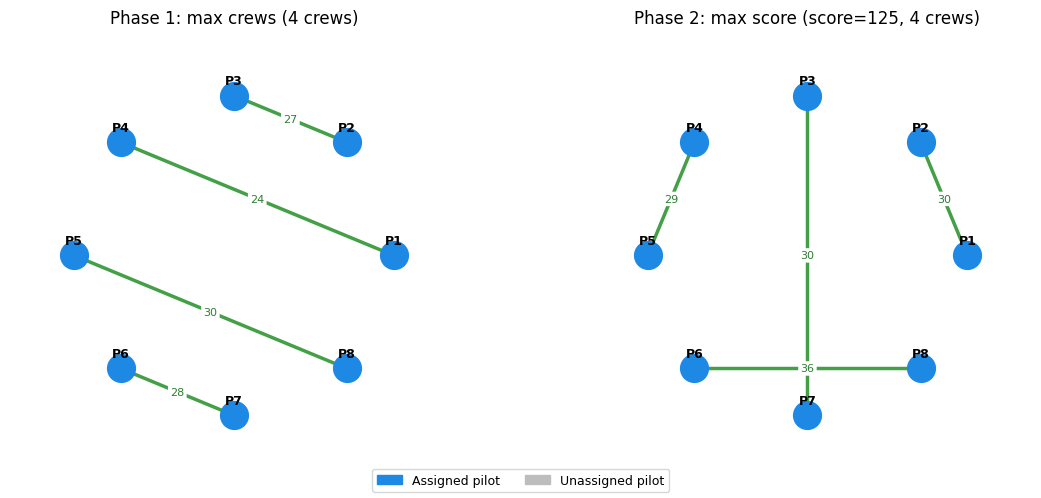

In [ ]:
if "crews" in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    import math

    def draw_crew_graph(ax, flying, title):
        n = 8
        # Circular layout
        angles = [2 * math.pi * i / n for i in range(n)]
        pos = {p+1: (math.cos(a), math.sin(a)) for p, a in enumerate(angles)}

        assigned = set()
        for a in flying:
            assigned.update(crews[a-1])

        # Draw all pilots
        for p in range(1, 9):
            color = "#1E88E5" if p in assigned else "#BDBDBD"
            ax.scatter(*pos[p], s=400, color=color, zorder=3)
            ax.annotate(f"P{p}", pos[p], textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=9, fontweight="bold")

        # Draw crew edges
        for a in flying:
            p, q = crews[a-1]
            x0, y0 = pos[p]; x1, y1 = pos[q]
            ax.plot([x0,x1], [y0,y1], color="#43A047", lw=2.5, zorder=2)
            ax.annotate(f"{scores[a]}", ((x0+x1)/2, (y0+y1)/2), fontsize=8,
                        color="#2E7D32", ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none"))

        ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(title)

    draw_crew_graph(axes[0], flying1,
                    f"Phase 1: max crews ({obj_nflying:.0f} crews)")
    draw_crew_graph(axes[1], flying2,
                    f"Phase 2: max score (score={obj_score:.0f}, {len(flying2)} crews)")

    blue_p = mpatches.Patch(color="#1E88E5", label="Assigned pilot")
    grey_p = mpatches.Patch(color="#BDBDBD", label="Unassigned pilot")
    fig.legend(handles=[blue_p, grey_p], loc="lower center", ncol=2, fontsize=9)
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping crew graph")

## F-3 Landing schedule (MIP)

*Applications Book Chapter F, Example 3*

> **Mosel model:** [`f3landing_p.mos`](models/air_transport/f3landing_p.mos)

Ten planes are scheduled to arrive at a large airport. Each plane has an earliest arrival time (`START`) and a latest arrival time (`STOP`), with a preferred target arrival time (`TARGET`) in between. Penalties are charged for each minute a plane lands early or late. Between any two consecutive landings, a minimum safety separation interval must be respected.

The disjunctive constraint (plane $p$ lands before or after plane $q$) is linearized using plane-specific BigM values $M_{p,q} = \text{STOP}_p + \text{DIST}_{p,q} - \text{START}_q$.

**Sets:** $\text{PLANES} = \{1, \ldots, 10\}$

**Parameters:** $\text{START}_p, \text{STOP}_p, \text{TARGET}_p$ - time window and target (minutes); $\text{CEARLY}_p, \text{CLATE}_p$ - penalty per minute; $\text{DIST}_{p,q}$ - minimum separation

**Decision variables:** $\mathit{land}_p \geq 0$ (actual landing time); $\mathit{early}_p, \mathit{late}_p \geq 0$ (deviation); $\mathit{prec}_{p,q} \in \{0,1\}$ (1 if $p$ lands before $q$)

$$
\begin{align*}
\text{minimize}   \quad & \sum_{p} (\text{CEARLY}_p \cdot \mathit{early}_p + \text{CLATE}_p \cdot \mathit{late}_p) \\
\text{subject to} \quad & \mathit{land}_p + \text{DIST}_{p,q} \leq \mathit{land}_q + M_{p,q} \cdot \mathit{prec}_{q,p} \quad \forall\, p > q \\
                          & \mathit{land}_p + \text{DIST}_{p,q} \leq \mathit{land}_q + M_{p,q} \cdot (1 - \mathit{prec}_{p,q}) \quad \forall\, p < q \\
                          & \mathit{early}_p \geq \text{TARGET}_p - \mathit{land}_p, \quad \mathit{late}_p \geq \mathit{land}_p - \text{TARGET}_p \quad \forall\, p
\end{align*}
$$

Define all input data as 1-indexed dicts. `DIST` is the 10x10 separation matrix: planes 1 and 2 need 3 minutes of separation (same aircraft type), all other pairs need 8 or 15 minutes. Pass `DIST` as a flat dict with `(p,q)` tuple keys.

In [ ]:
START  = {i: v for i, v in enumerate([129,195, 89, 96,110,120,124,126,135,160], 1)}
TARGET = {i: v for i, v in enumerate([155,258, 98,106,123,135,138,140,150,180], 1)}
STOP   = {i: v for i, v in enumerate([559,744,510,521,555,576,577,573,591,657], 1)}
CEARLY = {i: v for i, v in enumerate([ 10, 10, 30, 30, 30, 30, 30, 30, 30, 30], 1)}
CLATE  = {i: v for i, v in enumerate([ 10, 10, 30, 30, 30, 30, 30, 30, 30, 30], 1)}

dist_rows = [
    [0,  3,15,15,15,15,15,15,15,15],
    [3,  0,15,15,15,15,15,15,15,15],
    [15,15, 0, 8, 8, 8, 8, 8, 8, 8],
    [15,15, 8, 0, 8, 8, 8, 8, 8, 8],
    [15,15, 8, 8, 0, 8, 8, 8, 8, 8],
    [15,15, 8, 8, 8, 0, 8, 8, 8, 8],
    [15,15, 8, 8, 8, 8, 0, 8, 8, 8],
    [15,15, 8, 8, 8, 8, 8, 0, 8, 8],
    [15,15, 8, 8, 8, 8, 8, 8, 0, 8],
    [15,15, 8, 8, 8, 8, 8, 8, 8, 0],
]
DIST_F3 = {(i+1, j+1): dist_rows[i][j] for i in range(10) for j in range(10)}

print(f"{'Plane':>6}  {'Earliest':>9}  {'Target':>7}  {'Latest':>7}  {'EarlyPen':>9}  {'LatePen':>8}")
for p in range(1, 11):
    print(f"  {p:>3}    {START[p]:>7}    {TARGET[p]:>6}   {STOP[p]:>6}   "
          f"  {CEARLY[p]:>6}/min    {CLATE[p]:>5}/min")

 Plane   Earliest   Target   Latest   EarlyPen   LatePen
    1        129       155      559         10/min       10/min
    2        195       258      744         10/min       10/min
    3         89        98      510         30/min       30/min
    4         96       106      521         30/min       30/min
    5        110       123      555         30/min       30/min
    6        120       135      576         30/min       30/min
    7        124       138      577         30/min       30/min
    8        126       140      573         30/min       30/min
    9        135       150      591         30/min       30/min
   10        160       180      657         30/min       30/min


Use the compile-load-run sequence. After solving, `sol_land` gives the actual landing time for each plane. The output dict also includes `TARGET`, `START`, and `STOP` so the results can be displayed alongside the input time windows without re-referencing the Python dicts.

In [ ]:
mp.compile_model(f"{MODELS}/f3landing_p.mos", f"{MODELS}/f3landing_p.bim")
model = mp.load_model(f"{MODELS}/f3landing_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"START": START, "STOP": STOP, "TARGET": TARGET,
                "CEARLY": CEARLY, "CLATE": CLATE, "DIST": DIST_F3},
)

if model.prob_status.is_solution_available:
    obj_val_f3 = output["obj_val"]
    sol_land   = {int(k): v for k, v in output["sol_land"].items()}

    print(f"Total deviation cost: {obj_val_f3:.2f}")
    print()
    print(f"{'Plane':>6}  {'Target':>7}  {'Actual':>7}  {'Dev (min)':>10}  {'Penalty':>8}")
    total_check = 0
    for p in range(1, 11):
        t   = TARGET[p]
        a   = sol_land[p]
        dev = a - t
        pen = CEARLY[p] * max(0, -dev) + CLATE[p] * max(0, dev)
        total_check += pen
        print(f"  {p:>3}    {t:>6}    {a:>6}    {dev:>+8.0f}   {pen:>7.0f}")
    print(f"{'Total':>43}   {total_check:>7.0f}")
else:
    print(f"No solution found ({model.prob_status})")

Total deviation cost: 700.00

 Plane   Target   Actual   Dev (min)   Penalty
    1       155    165.00000000000003         +10       100
    2       258     258.0          +0         0
    3        98      98.0          +0         0
    4       106     106.0          +0         0
    5       123    117.99999999999996          -5       150
    6       135    125.99999999999997          -9       270
    7       138     134.0          -4       120
    8       140     142.0          +2        60
    9       150     150.0          +0         0
   10       180     180.0          +0         0
                                      Total       700


Gantt-style chart of the landing schedule. For each plane, the grey bar spans the full **arrival window** - the range `[START, STOP]` within which the plane is permitted to land. The black tick marks the **target** (preferred) time within that window. The colored dot shows the **actual scheduled** landing time.

Planes landing before their target are shown in blue (early); after their target in orange (late). All actual landings remain inside the grey window - no plane lands outside its permitted range. Penalties arise purely from deviation from the target: even a landing a few minutes early or late but well inside the window incurs a cost. This deviation is often forced by the minimum separation constraints between consecutive landings.

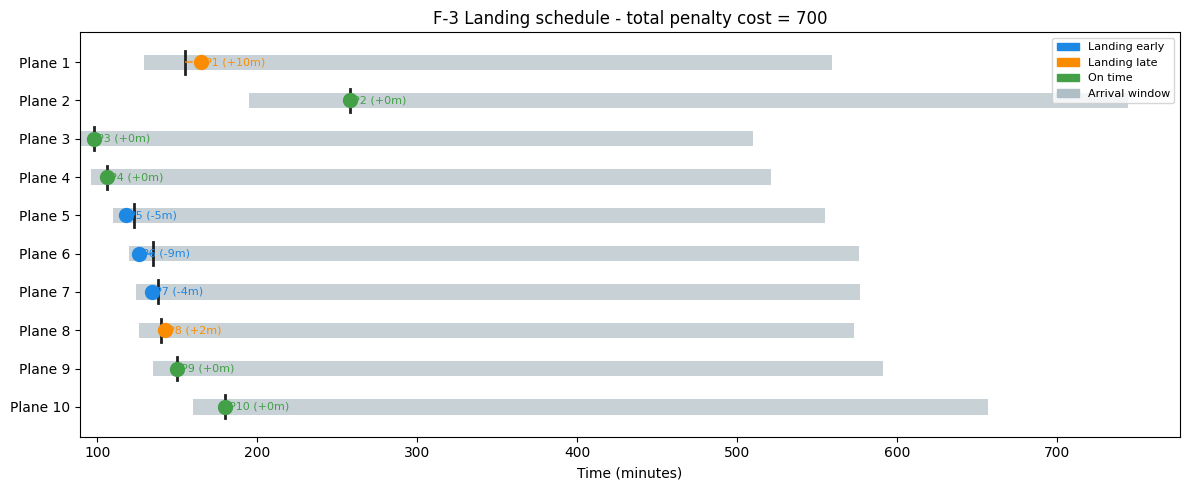

In [ ]:
if "sol_land" in locals():
    fig, ax = plt.subplots(figsize=(12, 5))

    for p in range(1, 11):
        y  = 11 - p  # top to bottom
        s  = START[p]; st = STOP[p]; t = TARGET[p]; a = sol_land[p]

        # Time window bar
        ax.barh(y, st - s, left=s, height=0.4, color="#B0BEC5", alpha=0.7)

        # Target tick
        ax.plot([t, t], [y-0.3, y+0.3], color="#212121", lw=2)

        # Actual landing
        color = "#1E88E5" if a < t else "#FB8C00" if a > t else "#43A047"
        ax.scatter(a, y, color=color, s=100, zorder=5)
        ax.plot([t, a], [y, y], color=color, lw=1.5, linestyle="--", alpha=0.7)

        dev = a - t
        ax.annotate(f"P{p} ({dev:+.0f}m)", (max(a, s)+2, y),
                    va="center", fontsize=8, color=color)

    ax.set_yticks(range(1, 11))
    ax.set_yticklabels([f"Plane {11-p}" for p in range(1, 11)])
    ax.set_xlabel("Time (minutes)")
    ax.set_title(f"F-3 Landing schedule - total penalty cost = {obj_val_f3:.0f}")

    early_p = mpatches.Patch(color="#1E88E5", label="Landing early")
    late_p  = mpatches.Patch(color="#FB8C00", label="Landing late")
    ontime_p= mpatches.Patch(color="#43A047", label="On time")
    win_p   = mpatches.Patch(color="#B0BEC5", label="Arrival window")
    ax.legend(handles=[early_p, late_p, ontime_p, win_p], fontsize=8, loc="upper right")

    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping landing schedule chart")

## F-4 Transatlantic freight hubs (MIP)

*Applications Book Chapter F, Example 4*

> **Mosel models:** [`f4hub_p.mos`](models/air_transport/f4hub_p.mos) (original), [`f4hub2_p.mos`](models/air_transport/f4hub2_p.mos) (improved)

An airline transports freight between 3 French cities (Marseille, Nice, Paris) and 3 American cities (Atlanta, Boston, Chicago). The airline wants to designate 2 cities as hubs: all freight between cities assigned to different hubs is routed through the hub-to-hub link, which benefits from a 20% distance discount. Which pair of hubs minimizes total transport cost?

The original formulation (`f4hub_p.mos`) creates $6^4 = 1296$ flow variables. The improved formulation (`f4hub2_p.mos`) exploits the geography: one hub must be in the US (cities 1-3), one in Europe (cities 4-6). Using a **dynamic array**, only valid routes are created — same-continent pairs share a hub, cross-continent pairs use one hub each side — reducing the number of variables significantly. This also makes the model tractable within the Xpress Community (free) variable limit. Transport costs are computed by an inline `calccost` function.

**Sets:** $\text{CITIES} = \{1, \ldots, 6\}$ (Atlanta, Boston, Chicago, Marseille, Nice, Paris)

**Parameters:** $\text{QUANT}_{i,j}$ - freight volume; $\text{DIST}_{i,j}$ - distance; $\text{FACTOR}=0.8$ (hub discount); $\text{COST}_{i,j,k,l} = \text{DIST}_{i,k} + 0.8 \cdot \text{DIST}_{k,l} + \text{DIST}_{l,j}$

**Decision variables:** $\mathit{hub}_i \in \{0,1\}$; $\mathit{flow}_{i,j,k,l} \in \{0,1\}$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i,j,k,l} \text{QUANT}_{i,j} \cdot \text{COST}_{i,j,k,l} \cdot \mathit{flow}_{i,j,k,l} \\
\text{subject to} \quad & \textstyle\sum_i \mathit{hub}_i = 2; \quad \sum_{k,l} \mathit{flow}_{i,j,k,l} = 1 \; \forall\, i,j; \quad \mathit{flow}_{i,j,k,l} \leq \mathit{hub}_k,\, \mathit{hub}_l
\end{align*}
$$

Define `DIST` and `QUANT` as dicts with `(i,j)` tuple keys (1-indexed). City names are provided as a 1-indexed dict and passed to the model so they can be included in the output. The transport cost reduction `FACTOR` is a scalar.

In [ ]:
NAMES = {1:"Atlanta", 2:"Boston", 3:"Chicago", 4:"Marseille", 5:"Nice", 6:"Paris"}

dist_rows = [
    [   0,  945,  605, 4667, 4749, 4394],
    [ 945,    0,  866, 3726, 3806, 3448],
    [ 605,  866,    0, 4471, 4541, 4152],
    [4667, 3726, 4471,    0,  109,  415],
    [4749, 3806, 4541,  109,    0,  431],
    [4394, 3448, 4152,  415,  431,    0],
]
quant_rows = [
    [   0,  500, 1000,  300,  400, 1500],
    [1500,    0,  250,  630,  360, 1140],
    [ 400,  510,    0,  460,  320,  490],
    [ 300,  600,  810,    0,  820,  310],
    [ 400,  100,  420,  730,    0,  970],
    [ 350, 1020,  260,  580,  380,    0],
]
DIST_F4  = {(i+1, j+1): dist_rows[i][j]  for i in range(6) for j in range(6)}
QUANT_F4 = {(i+1, j+1): quant_rows[i][j] for i in range(6) for j in range(6)}
FACTOR   = 0.8

total_vol = sum(quant_rows[i][j] for i in range(6) for j in range(6))
print(f"Cities: {list(NAMES.values())}")
print(f"Total freight volume: {total_vol:,} units across {6*6 - 6} city pairs")

Cities: ['Atlanta', 'Boston', 'Chicago', 'Marseille', 'Nice', 'Paris']
Total freight volume: 17,810 units across 30 city pairs


Use the compile-load-run sequence. After loading the model, inspect its metadata using `model.name`, `model.version`, `model.user_comment`, and `model.size` before running the solve. These introspection properties are available on any loaded model without executing it.

In [ ]:
mp.compile_model(f"{MODELS}/f4hub2_p.mos", f"{MODELS}/f4hub2_p.bim")
model = mp.load_model(f"{MODELS}/f4hub2_p.bim")
model.set_default_stream(mp.StreamType.OUTPUT, "null:")

# Model introspection - available after load, before run
print("Model metadata:")
print(f"  name:    {model.name}")
print(f"  version: {model.version}")
print(f"  size:    {model.size:,} bytes")
if model.user_comment:
    print(f"  comment: {model.user_comment}")
print()

output = model.run(
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"QUANT": QUANT_F4, "DIST": DIST_F4, "FACTOR": FACTOR, "NAMES": NAMES},
)

if model.prob_status.is_solution_available:
    obj_val_f4 = output["obj_val"]
    sol_hub    = output["sol_hub"]

    hub_indices = [i for i in range(1, 7) if sol_hub.get(i, 0) > 0.5]
    hub_names   = [NAMES[i] for i in hub_indices]

    print(f"Minimum total transport cost: {obj_val_f4:,.0f}")
    print(f"Selected hubs: {hub_names}")
else:
    print(f"No solution found ({model.prob_status})")

Model metadata:
  name:    F-4 Hubs (2)
  version: 0
  size:    11,792 bytes

Minimum total transport cost: 42,153,794
Selected hubs: ['Boston', 'Paris']


Bar chart comparing total freight volume handled through each city pair's hub-and-spoke routing. The selected hubs are highlighted.

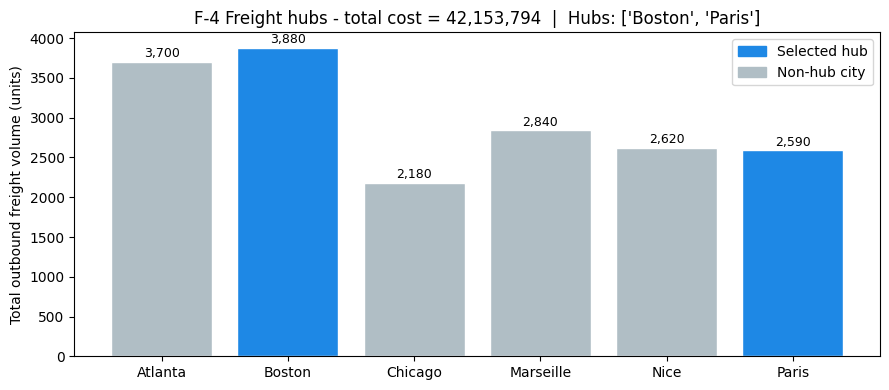

In [ ]:
if "sol_hub" in locals():
    fig, ax = plt.subplots(figsize=(9, 4))

    cities = list(NAMES.values())
    colors = ["#1E88E5" if sol_hub.get(i, 0) > 0.5 else "#B0BEC5" for i in range(1, 7)]

    # Show total outbound freight volume per city
    outbound = [sum(quant_rows[i][j] for j in range(6)) for i in range(6)]

    bars = ax.bar(cities, outbound, color=colors, edgecolor="white")
    for bar, vol in zip(bars, outbound):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{vol:,}", ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Total outbound freight volume (units)")
    ax.set_title(f"F-4 Freight hubs - total cost = {obj_val_f4:,.0f}  |  Hubs: {hub_names}")

    hub_p  = mpatches.Patch(color="#1E88E5", label="Selected hub")
    city_p = mpatches.Patch(color="#B0BEC5", label="Non-hub city")
    ax.legend(handles=[hub_p, city_p])
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping hub chart")

## F-5 Flight tour planning (MIP)

*Applications Book Chapter F, Example 5*

> **Mosel model:** [`f5tour_p.mos`](models/air_transport/f5tour_p.mos)

A government in south-east Asia needs to establish an air supply route from the capital (city 1) visiting 6 other airports and returning. Only 7 runways are usable. The model finds the minimum-distance Hamiltonian tour. Since the distance matrix is symmetric, the `.dat` file stores only the upper triangle; the model fills the lower triangle automatically.

The initial LP relaxation typically produces subtours. The model uses a recursive procedure `breaksubtour` that identifies the smallest subtour, adds an elimination constraint, and re-solves until a valid Hamiltonian tour is found.

**Sets:** $\text{CITIES} = \{1, \ldots, 7\}$ (city 1 = capital)

**Parameters:** $\text{DIST}_{i,j}$ - distance between airports $i$ and $j$ (symmetric)

**Decision variables:** $\mathit{fly}_{i,j} \in \{0,1\}$ - 1 if the tour goes directly from city $i$ to $j$

$$
\begin{align*}
\text{minimize}   \quad & \sum_{i \neq j} \text{DIST}_{i,j} \cdot \mathit{fly}_{i,j} \\
\text{subject to} \quad & \sum_{j \neq i} \mathit{fly}_{i,j} = 1 \; \forall\, i, \quad \sum_{i \neq j} \mathit{fly}_{i,j} = 1 \; \forall\, j \\
                          & \sum_{i \in S} \mathit{fly}_{i, \text{NEXT}(i)} \leq |S| - 1 \quad \text{for each subtour } S \subsetneq \text{CITIES}
\end{align*}
$$

The symmetric distance matrix is given as the upper triangle only. Pass the full symmetric matrix to MoselPy as a flat dict with `(i,j)` tuple keys; the Mosel model calls `DIST(j,i) := DIST(i,j)` after reading, which is harmless when the full matrix is already present. For standalone execution from the `.dat` file, the upper triangle format is preserved.

In [ ]:
# Upper triangle values from the .dat file
upper_vals = [786,549,657,331,559,250, 668,979,593,224,905, 316,607,472,467, 890,769,400, 386,559, 681]
pairs = [(i,j) for i in range(1,8) for j in range(i+1,8)]
dist_upper = {pairs[k]: upper_vals[k] for k in range(len(pairs))}

# Build full symmetric matrix for Python input
DIST_F5 = {}
for (i,j), v in dist_upper.items():
    DIST_F5[(i,j)] = v
    DIST_F5[(j,i)] = v

city_names = ["Capital", "City 2", "City 3", "City 4", "City 5", "City 6", "City 7"]
print(f"Airports: {7}  |  Distance range: {min(dist_upper.values())} - {max(dist_upper.values())} km")

# Show distance matrix
dm = pd.DataFrame(
    [[DIST_F5.get((i,j), 0) for j in range(1,8)] for i in range(1,8)],
    index=[f"C{i}" for i in range(1,8)],
    columns=[f"C{j}" for j in range(1,8)],
)
print("Distance matrix (km):")
print(dm.to_string())

Airports: 7  |  Distance range: 224 - 979 km
Distance matrix (km):
     C1   C2   C3   C4   C5   C6   C7
C1    0  786  549  657  331  559  250
C2  786    0  668  979  593  224  905
C3  549  668    0  316  607  472  467
C4  657  979  316    0  890  769  400
C5  331  593  607  890    0  386  559
C6  559  224  472  769  386    0  681
C7  250  905  467  400  559  681    0


Use the context manager form of `mp.load_model()`. The `with` statement ensures model resources are released automatically when the block exits, even if an exception occurs. This is the recommended pattern when the model is used once and will not be reused. The `breaksubtour` recursive procedure runs entirely inside Mosel, adding subtour elimination cuts as needed and re-solving until a valid Hamiltonian tour is found.

**Note on alternative optimal solutions:** The tour produced here may visit the airports in a different order than the standalone `mosel exec` run, but both achieve the same minimum distance of 2575 km. TSP problems typically have multiple optimal tours - any cyclic permutation or reversal of a tour yields an equally valid solution with the same total distance.

In [ ]:
mp.compile_model(f"{MODELS}/f5tour_p.mos", f"{MODELS}/f5tour_p.bim")

with mp.load_model(f"{MODELS}/f5tour_p.bim") as model:
    model.set_default_stream(mp.StreamType.OUTPUT, "null:")
    output = model.run(
        exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
        input_data={"DIST": DIST_F5},
    )
    prob_ok = model.prob_status.is_solution_available

# model resources freed here

if prob_ok:
    obj_val_f5 = output["obj_val"]
    nextc_raw  = output["NEXTC"]
    NEXTC = {int(i): int(v) for i, v in nextc_raw.items()}

    # Reconstruct tour starting from city 1
    tour = [1]
    current = 1
    for _ in range(6):
        current = NEXTC[current]
        tour.append(current)
    tour.append(1)  # return to capital

    print(f"Minimum tour distance: {obj_val_f5:.0f} km")
    print(f"Tour: {' -> '.join(city_names[c-1] for c in tour)}")
    total = sum(DIST_F5[(tour[k], tour[k+1])] for k in range(7))
    print()
    print(f"{'Leg':<6}  {'From':<10}  {'To':<10}  {'Distance':>10}")
    for k in range(7):
        a, b = tour[k], tour[k+1]
        print(f"  {k+1:<4}  {city_names[a-1]:<10}  {city_names[b-1]:<10}  {DIST_F5[(a,b)]:>8} km")
    print(f"{'Total':>30}   {total:>8} km")
else:
    print("No solution found")

Minimum tour distance: 2575 km
Tour: Capital -> City 7 -> City 4 -> City 3 -> City 2 -> City 6 -> City 5 -> Capital

Leg     From        To            Distance
  1     Capital     City 7           250 km
  2     City 7      City 4           400 km
  3     City 4      City 3           316 km
  4     City 3      City 2           668 km
  5     City 2      City 6           224 km
  6     City 6      City 5           386 km
  7     City 5      Capital          331 km
                         Total       2575 km


Tour visualization using a circular layout for the 7 airports. Arrows show the flight sequence; the capital (city 1) is highlighted in red.

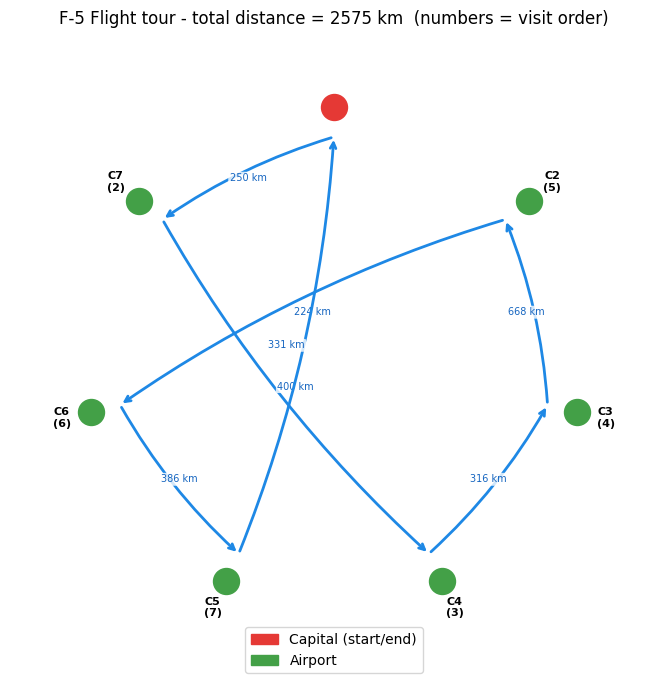

In [ ]:
if "tour" in locals():
    import math
    fig, ax = plt.subplots(figsize=(7, 7))

    n = 7
    angles = [math.pi/2 - 2*math.pi*i/n for i in range(n)]  # start at top
    pos = {i+1: (math.cos(angles[i]), math.sin(angles[i])) for i in range(n)}

    # Draw tour arrows
    for k in range(7):
        a, b = tour[k], tour[k+1]
        x0, y0 = pos[a]; x1, y1 = pos[b]
        ax.annotate("", xy=(x1*0.88, y1*0.88), xytext=(x0*0.88, y0*0.88),
                    arrowprops=dict(arrowstyle="->", color="#1E88E5", lw=2,
                                   connectionstyle="arc3,rad=0.08"))
        mx, my = (x0+x1)/2*0.88, (y0+y1)/2*0.88
        ax.text(mx, my, f"{DIST_F5[(a,b)]} km", ha="center", va="center",
                fontsize=7, color="#1565C0",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    # Draw city nodes
    for c in range(1, 8):
        x, y = pos[c]
        color = "#E53935" if c == 1 else "#43A047"
        ax.scatter(x, y, s=350, color=color, zorder=5)
        offset_x = x * 0.12; offset_y = y * 0.12
        order = tour.index(c) + 1
        ax.annotate(f"C{c}\n({order})", (x + offset_x, y + offset_y),
                    ha="center", va="center", fontsize=8, fontweight="bold",
                    color="white" if c == 1 else "black")

    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"F-5 Flight tour - total distance = {obj_val_f5:.0f} km  (numbers = visit order)")

    cap_p  = mpatches.Patch(color="#E53935", label="Capital (start/end)")
    city_p = mpatches.Patch(color="#43A047", label="Airport")
    ax.legend(handles=[cap_p, city_p], loc="lower center")
    plt.tight_layout(); plt.show()
else:
    print("No solution available - skipping tour chart")

### F-5 Variant: callback-based subtour elimination

> **Mosel model:** [`f5tour_cb_p.mos`](models/air_transport/f5tour_cb_p.mos)

The sequential re-solve approach in `f5tour_p.mos` works but restarts the MIP each time a subtour is found. A cleaner alternative registers a **`XPRS_CB_PREINTSOL` callback** inside Mosel: every time the solver finds an integer solution, the callback fires and checks for subtours before the solution is accepted.

- **Heuristic solutions** (`isheur=true`): subtours are rejected immediately with `rejectintsol` — no cuts can be added for heuristic solutions.
- **B&B node solutions** (`isheur=false`): for each subtour $S$ found, two lazy cuts are injected via `addcuts` and the node LP is re-solved with the new constraints active. The solver never needs to restart.

Setting `XPRS_MIPDUALREDUCTIONS=0` is required so the solver does not apply dual reductions based on an incomplete constraint set.

From Python's perspective, `execute_model` is called **once** and the full B&B with lazy constraint generation happens automatically inside Mosel.

Use the single execution command. The model registers the callback, sets the required parameters, and solves. All subtour elimination happens inside Mosel during B&B; Python receives only the final tour.

In [ ]:
model_cb, output_cb = mp.execute_model(
    f"{MODELS}/f5tour_cb_p.mos",
    exec_params={"DATASOURCE": "moselpy:", "OUTFILE": "moselpy:"},
    input_data={"DIST": DIST_F5},
)

if model_cb.prob_status.is_solution_available:
    obj_cb  = output_cb["obj_val"]
    nextc_cb = output_cb["NEXTC"]

    tour_cb = [1]
    current = 1
    for _ in range(len(nextc_cb) - 1):
        current = round(nextc_cb.get(current, 0))
        tour_cb.append(current)
    tour_cb.append(1)

    print(f"Callback version - minimum tour distance: {obj_cb:.0f}")
    print(f"Tour: {' -> '.join(str(c) for c in tour_cb)}")
    print()
    print(f"Both approaches give same result: {abs(obj_cb - obj_val_f5) < 1}")
else:
    print(f"No solution found ({model_cb.prob_status})")

Callback version - minimum tour distance: 2575
Tour: 1 -> 7 -> 4 -> 3 -> 2 -> 6 -> 5 -> 1

Both approaches give same result: True
